so the


a= neuron's output is = 0.7685
 c= when we double the waight so it would be closer to 1 so it nears the saturation
 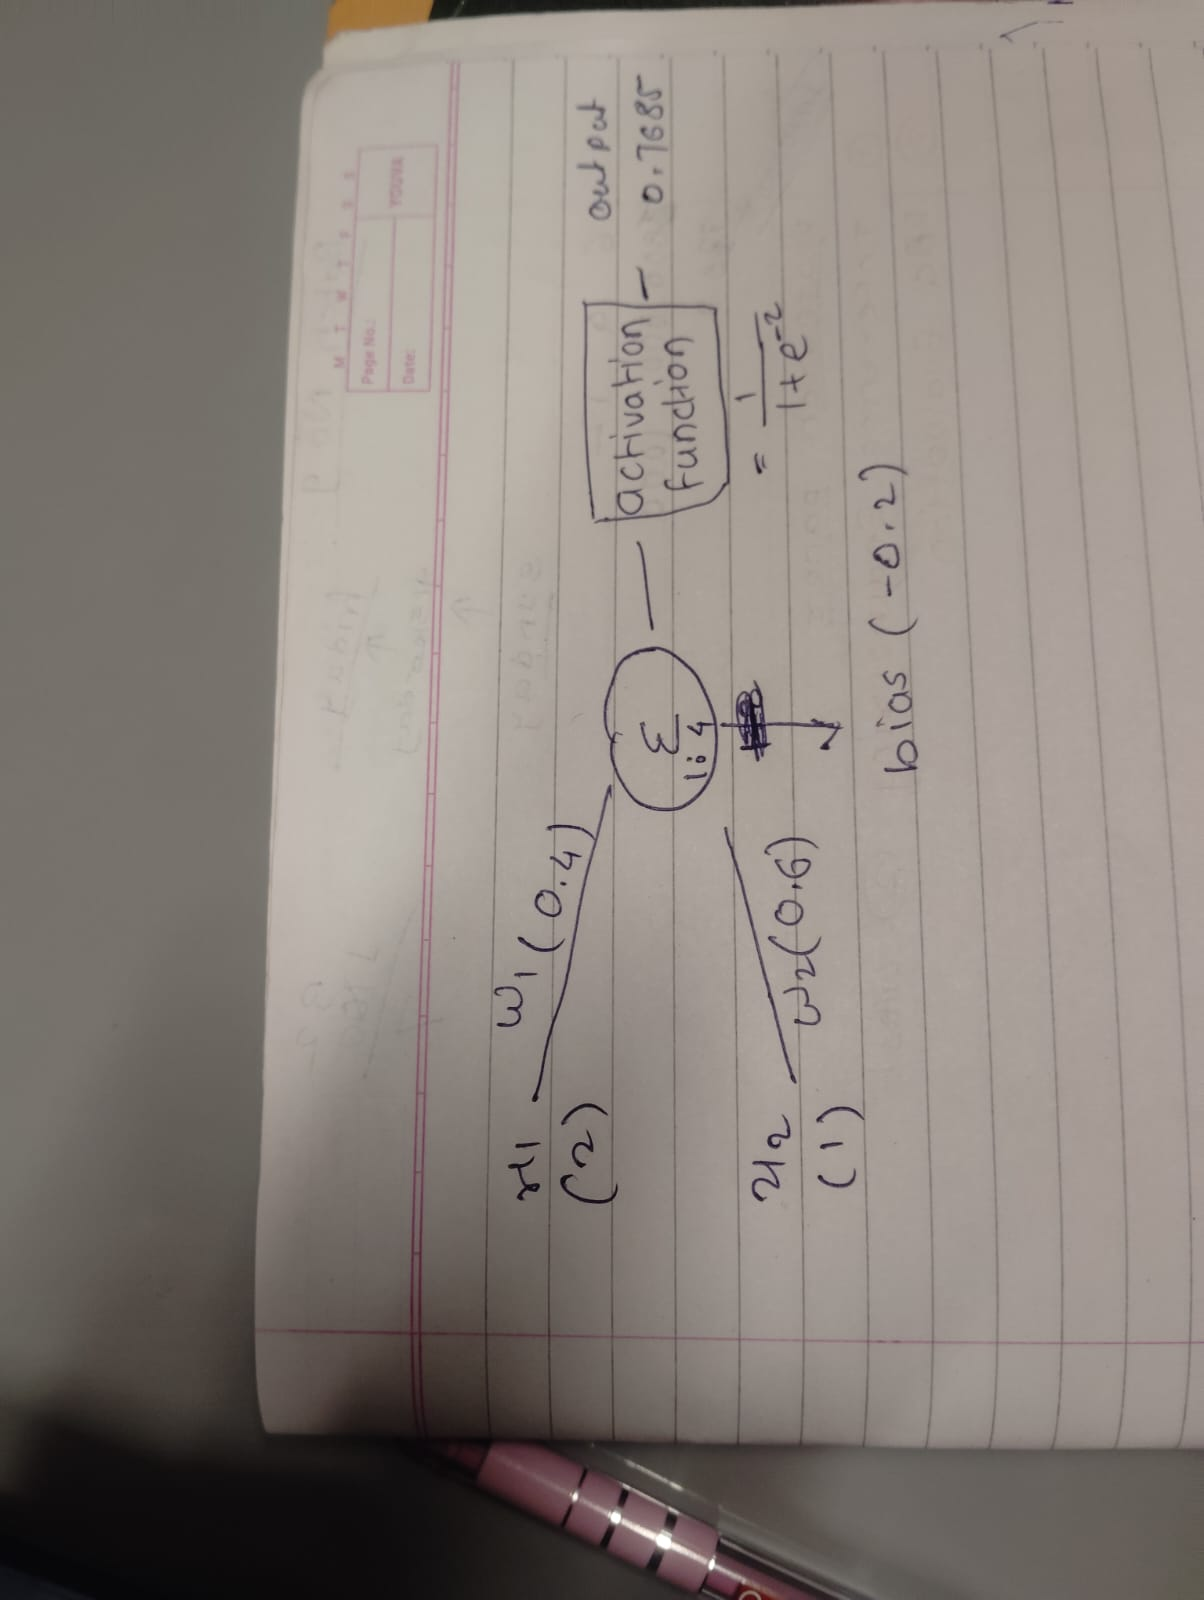

###Test Set 2

In [1]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import pytorch library run our nn model, import nn form  torch

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


so we wan't to use accelerator but we don't if it not found then we simply use cpu as our device

In [42]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

so we defining the class and sub class as nn.module and initializing the neuralnetwork

we perform  our our calculation part in forward method on input data

In [43]:

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [44]:

X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([2])


In [40]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [41]:
X = torch.rand(1, -1.0, -1.0, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

TypeError: rand(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got float"

so we get the error  rand(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got float"  it should only be int but it get float so it gives error



In [45]:
input_image = torch.rand(3,28,28)
print(input_image.size())

torch.Size([3, 28, 28])


In [46]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())


torch.Size([3, 784])


Attention lets the model focus on relevant words


there are 8 words

attention means

In [48]:
import datasets
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm


In [49]:
pipe = pipeline("text-classification")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999872088432312}]

In [51]:
pipe(["This restaurant is awesome", "This restaurant is shit"])

[{'label': 'POSITIVE', 'score': 0.9998743534088135},
 {'label': 'NEGATIVE', 'score': 0.9997090697288513}]

in this output we clearly say it gives almost same score for both the text and it will be classify our text with right  acccuracy.
there are two opinions one is positive about restaurant and second one is negative so pipline can simplyfied it very easily and it gives accuracy almost high  

In [54]:
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1", padding_side="left")
model_inputs = tokenizer(["A list of colors: red, blue"], return_tensors="pt").to(model.device)

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

tokenizer.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [56]:
generated_ids = model.generate(**model_inputs)
tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
"A list of colors: red, blue, green, yellow, orange, purple, pink,"

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


'A list of colors: red, blue, green, yellow, orange, purple, pink,'

In [61]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.1", device_map="auto")
print(model.generation_config)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [59]:
# enable beam search sampling strategy
model.generate(**inputs, num_beams=4, do_sample=True)

NameError: name 'inputs' is not defined